## Simple Linear Regration

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
df = pd.read_csv('data.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


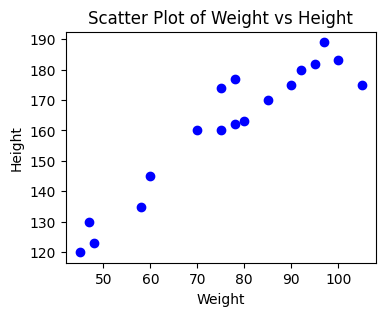

In [5]:
plt.figure(figsize=(4,3))
plt.scatter(df['Weight'], df['Height'], color='blue')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Scatter Plot of Weight vs Height')
plt.show()


In [6]:
#Check data type with assinging x and y variables
x =df[['Weight']]
y = df['Height']
print(type(x))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


## Train the Data using scikit learn

In [7]:
from sklearn.model_selection import train_test_split #importing train_test_split function from sklearn library

#x_train = feature for training the model
#x_test = feature for testing the model
#y_train = lable for training the model
#y_test = lable for testing the model
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42) #splitting the data into training and testing sets

In [8]:
#Feature Scaling using StandardScaler
from sklearn.preprocessing import StandardScaler #importing StandardScaler class from sklearn library
scaler = StandardScaler() #creating an instance of StandardScaler class
x_train_scaled = scaler.fit_transform(x_train) #scaling the training feature data

#IMP for interview question
x_test_scaled = scaler.transform(x_test) #scaling the testing feature data the leakage prevantion technique is used here by using transform method instead of fit_transform method for testing data


In [11]:
from sklearn.linear_model import LinearRegression #importing LinearRegression class from sklearn library

regression = LinearRegression() #creating an instance of LinearRegression class
regression.fit(x_train_scaled, y_train) #fitting the linear regression model to the training data


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
print(regression.coef_) #printing the coefficient of the linear regression model
print(regression.intercept_) #printing the intercept of the linear regression model

[17.34878444]
164.57142857142858


In [16]:
y_pred = regression.predict(x_test_scaled) #predicting the target variable for the testing data using the fitted linear regression model

In [17]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score #importing mean_absolute_error, root_mean_squared_error, r2_score functions from sklearn library

rmse = root_mean_squared_error(y_test, y_pred) #calculating the root mean squared error
mae = mean_absolute_error(y_test, y_pred) #calculating the mean absolute error
r2 = r2_score(y_test, y_pred) #calculating the R-squared score

print(rmse)
print(mae)  
print(r2)

7.121388316302994
5.706333648776528
0.9115225444525974


In [ ]:
#is  the model underfitting or overfitting

y_pred_train = regression.predict(x_train) #predicting the target variable for the training data using the fitted linear regression model

r2_score_train = r2_score(y_train, y_pred_train) #calculating the R-squared score for the training data
r2_score_test = r2_score(y_test, y_pred) #calculating the R-squared score for the testing data
print("train:", r2_score_train)
print("test:", r2_score_test)

#train ~ test => good model
#train > test => overfitting
#train < test => underfitting
